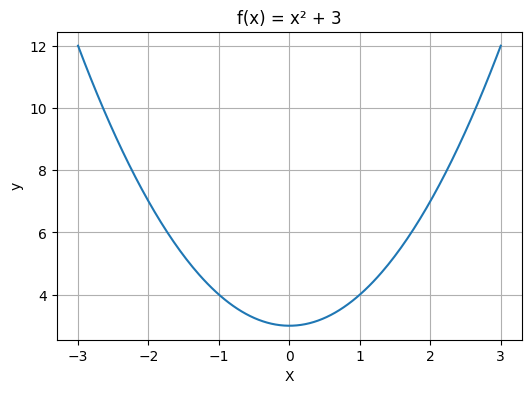

Nodes: [2], Epochs: 50 → Train MSE: 24.8498, Test MSE: 17.6019
Nodes: [2], Epochs: 50 → Train MSE: 24.8498, Test MSE: 17.6019
Nodes: [2], Epochs: 50 → Train MSE: 24.8498, Test MSE: 17.6019
Nodes: [2], Epochs: 100 → Train MSE: 20.7623, Test MSE: 14.5908
Nodes: [2], Epochs: 150 → Train MSE: 19.4877, Test MSE: 13.6886
Nodes: [2], Epochs: 200 → Train MSE: 18.4593, Test MSE: 12.8124
Nodes: [2], Epochs: 300 → Train MSE: 13.6040, Test MSE: 8.7671
Nodes: [2], Epochs: 400 → Train MSE: 3.5095, Test MSE: 2.4768
Nodes: [2], Epochs: 500 → Train MSE: 1.6631, Test MSE: 1.4841
Nodes: [4], Epochs: 50 → Train MSE: 17.3783, Test MSE: 12.1139
Nodes: [4], Epochs: 100 → Train MSE: 8.9839, Test MSE: 6.0488
Nodes: [4], Epochs: 150 → Train MSE: 3.9458, Test MSE: 2.4666
Nodes: [4], Epochs: 200 → Train MSE: 1.4381, Test MSE: 0.7968
Nodes: [4], Epochs: 300 → Train MSE: 0.5157, Test MSE: 0.3684
Nodes: [4], Epochs: 400 → Train MSE: 0.4444, Test MSE: 0.3520
Nodes: [4], Epochs: 500 → Train MSE: 0.4209, Test MSE: 0.33

In [ ]:
# Generate dataset for the range [-3,3] with 200 sample
# Implementation comes this cell
import numpy as np

X = np.linspace(-3, 3, 200).reshape(-1, 1) # input dataset
y = X**2 + 3 # target dataset

# Plot the sample
# Implementation comes to this 
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
#plt.scatter(X, y)
plt.plot(X, y)
plt.title("f(x) = x² + 3")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

# Shuffle the dataset and split it:
# training set 80%
# test set 20%
# Implementation comes this cell
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

# Define neural network using Keras Function API
# Input layer = 1 node i.e. one feature, value of x-axis
# 1 hidden layer = 2-4 nodes.  Dense with 'relu' activation function in each hidden layer
# Second order equation is nonlinear function, so we can't use linear activation function. 
# Output layer = 1 node (due to regression, only one node is enought in the output layer)

# Implementation comes this cell
# Print the structure of model: model.summary()

# import tensorflow as tf
# from tensorflow import keras
# from keras import layers

# inputs = keras.Input(shape=(1,))
# hidden = layers.Dense(4, activation='relu')(inputs)
# outputs = layers.Dense(1)(hidden)
# model = keras.Model(inputs=inputs, outputs=outputs)

# Model lives in tensorflow.keras.models — it's the class used to assemble a network (whether built via Functional API, as you're doing, or Sequential, or subclassing).
# Input and Dense live in tensorflow.keras.layers — this module holds all layer types (Dense, Conv2D, LSTM, Dropout, etc.), and Input is technically a special helper function (not a "layer" in the strict sense) that also lives here for convenience.

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ## This is to see the impact of number of nodes in the hidden layer and number of epochs on the performance of the model.
# def try_config(n_nodes, n_epochs):
#     inputs = Input(shape=(1,))
#     hidden = Dense(n_nodes, activation='relu')(inputs)
#     outputs = Dense(1)(hidden)
#     model = Model(inputs=inputs, outputs=outputs)
#     model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    
#     history = model.fit(X_train, y_train, epochs=n_epochs, verbose=0)
#     train_loss = history.history['loss'][-1]
    
#     test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    
#     print(f"nodes={n_nodes}, epochs={n_epochs} -> train_loss={train_loss:.3f}, test_loss={test_loss:.3f}")
#     return train_loss, test_loss

# print("nodes=2, epochs=100:", try_config(2, 100))
# print("nodes=4, epochs=100:", try_config(4, 100))
# print("nodes=8, epochs=100:", try_config(8, 100))
# print("nodes=2, epochs=100:", try_config(2, 100))
# print("nodes=4, epochs=100:", try_config(4, 100))
# print("nodes=8, epochs=100:", try_config(8, 100))
# print("nodes=2, epochs=100:", try_config(2, 100))
# print("nodes=4, epochs=100:", try_config(4, 100))
# print("nodes=8, epochs=100:", try_config(8, 100))
# print("nodes=2, epochs=200:", try_config(2, 200))
# print("nodes=4, epochs=200:", try_config(4, 200))
# print("nodes=8, epochs=200:", try_config(8, 200))
# print("nodes=2, epochs=200:", try_config(2, 200))
# print("nodes=4, epochs=200:", try_config(4, 200))
# print("nodes=8, epochs=200:", try_config(8, 200))
import tensorflow as tf

def run_experiment(nodes, epochs):
    # Fix random seed so results are reproducible
    tf.keras.utils.set_random_seed(42) 
    #tf.random.set_seed(42)
    
    # Build model: nodes is a list, e.g. [8] or [4, 8]
    inputs = Input(shape=(1,))
    x = inputs
    for n in nodes:
        x = Dense(n, activation='relu')(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)

    # Train
    model.compile(optimizer='adam', loss='mse')
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0)

    # Evaluate
    train_mse = model.evaluate(X_train, y_train, verbose=0)
    test_mse = model.evaluate(X_test, y_test, verbose=0)
    print(f"Nodes: {nodes}, Epochs: {epochs} → Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")
    return model

for nodes in [[2], [4], [8], [10]]:
    for epochs in [50, 100, 150, 200, 300, 400, 500]:
        run_experiment(nodes, epochs)
